In [127]:
import numpy as np
import numpy.linalg as nplg
import numpy.random as npra
from Finite_Optimal_User import dis_reward
from Myopic_User import *
from Three_State_Whittle_Index_user import *
from Multi_Arm_Bandit_Machine import MABM
from policy_curve_evaluation import expected_index_policy_curve
from single_arm_t2_whittle_index import (
    SearchConfig,
    compute_residual,
    compute_single_arm_finite_t2_whittle_index,
    compute_single_arm_t2_whittle_index,
)

if not hasattr(np, "float"):   np.float   = float
if not hasattr(np, "int"):     np.int     = int
if not hasattr(np, "complex"): np.complex = complex

In [128]:
from matplotlib.font_manager import FontManager
fm = FontManager()
mat_fonts = set(f.name for f in fm.ttflist)
#print(mat_fonts)
plt.rcParams['font.family'] = 'DejaVu Sans'

In [129]:
# Main experiment uses a fixed calibrated instance.
# Set SCENARIO = 'random' only when you want to search new examples.
SCENARIO = 'calibrated'
ORDER_START_SLOT = 2

arm_num = 7
state_num = 3
active_num = 1
time = 6
beta = 0.9999
sim_rounds = 1000

reward_set = np.array([
    [0.        , 0.9327329 , 2.59378966],
    [0.        , 0.76644555, 1.76342813],
    [0.        , 1.19457319, 1.19457319],
    [0.        , 1.37282365, 1.37282365],
    [0.        , 0.08414213, 2.08288997],
    [0.        , 0.13153239, 1.12733997],
    [0.        , 2.30016941, 2.89956591],
])

initial_dist = np.array([
    [0.20839664, 0.08089748, 0.71070588],
    [0.36480047, 0.23000444, 0.40519509],
    [0.02737932, 0.42386505, 0.54875563],
    [0.56644794, 0.3869826 , 0.04656946],
    [0.24167112, 0.62660437, 0.13172452],
    [0.61121311, 0.00382479, 0.3849621 ],
    [0.30820311, 0.093238  , 0.5985589 ],
])

transition_matrics = np.array([
    [[0.00188447, 0.13021329, 0.86790224],
     [0.45080727, 0.18756669, 0.36162603],
     [0.84217167, 0.08189174, 0.07593659]],
    [[0.17147064, 0.20485371, 0.62367565],
     [0.36546876, 0.13962824, 0.494903  ],
     [0.39298142, 0.10981969, 0.49719889]],
    [[0.14778902, 0.44116564, 0.41104534],
     [0.47202465, 0.22050983, 0.30746552],
     [0.23601746, 0.35346869, 0.41051385]],
    [[0.01624725, 0.51682392, 0.46692883],
     [0.28165465, 0.02234235, 0.696003  ],
     [0.21565882, 0.44326555, 0.34107563]],
    [[0.72261081, 0.01895057, 0.25843863],
     [0.17812287, 0.50117464, 0.32070248],
     [0.04845263, 0.53881865, 0.41272872]],
    [[0.41558332, 0.35368174, 0.23073493],
     [0.54845188, 0.13677096, 0.31477716],
     [0.02030356, 0.39863886, 0.58105758]],
    [[0.57383442, 0.26381177, 0.16235381],
     [0.06516066, 0.47698946, 0.45784988],
     [0.17121115, 0.62726038, 0.20152847]],
])

if SCENARIO == 'random':
    reward_set = np.array([0, 1, 8], dtype=float)
    reward_set = np.array([reward_set for _ in range(arm_num)])

In [130]:
if SCENARIO == 'random':
    transition_matrics = np.array([[[0.20, 0.30, 0.50], [0.60, 0.25, 0.15], [0.85, 0.10, 0.05]],
                                   [[0.05, 0.20, 0.75], [0.05, 0.20, 0.75], [0.10, 0.15, 0.75]],
                                   [[0.50, 0.30, 0.20], [0.15, 0.25, 0.60], [0.05, 0.10, 0.85]],
                                   [[0.25, 0.40, 0.35], [0.55, 0.30, 0.15], [0.80, 0.15, 0.05]],
                                   [[0.30, 0.50, 0.20], [0.10, 0.25, 0.65], [0.05, 0.15, 0.80]],
                                   [[0.15, 0.70, 0.15], [0.35, 0.30, 0.35], [0.70, 0.20, 0.10]],
                                   [[0.20, 0.60, 0.20], [0.25, 0.50, 0.25], [0.20, 0.60, 0.20]]])
transition_matrics

array([[[0.00188447, 0.13021329, 0.86790224],
        [0.45080727, 0.18756669, 0.36162603],
        [0.84217167, 0.08189174, 0.07593659]],

       [[0.17147064, 0.20485371, 0.62367565],
        [0.36546876, 0.13962824, 0.494903  ],
        [0.39298142, 0.10981969, 0.49719889]],

       [[0.14778902, 0.44116564, 0.41104534],
        [0.47202465, 0.22050983, 0.30746552],
        [0.23601746, 0.35346869, 0.41051385]],

       [[0.01624725, 0.51682392, 0.46692883],
        [0.28165465, 0.02234235, 0.696003  ],
        [0.21565882, 0.44326555, 0.34107563]],

       [[0.72261081, 0.01895057, 0.25843863],
        [0.17812287, 0.50117464, 0.32070248],
        [0.04845263, 0.53881865, 0.41272872]],

       [[0.41558332, 0.35368174, 0.23073493],
        [0.54845188, 0.13677096, 0.31477716],
        [0.02030356, 0.39863886, 0.58105758]],

       [[0.57383442, 0.26381177, 0.16235381],
        [0.06516066, 0.47698946, 0.45784988],
        [0.17121115, 0.62726038, 0.20152847]]])

In [131]:
def gen_P():
    P = npra.rand(3,3)
    P = P/P.sum(axis = 1).reshape((3, 1))
    return P
def gen_w(N):
    w = npra.rand(N, 3)
    w = w/w.sum(axis = 1).reshape(N, 1)
    return w
def gen_B(N):
    B = npra.rand(N,3)
    while (B[:, 2] < B[:, 1]).any():
        B[:, 2] = npra.rand(N)
    B[:, 0] = 0
    return B

In [132]:
if SCENARIO == 'random':
    for k in range(7):
        transition_matrics[k] = gen_P()

In [133]:
transition_matrics

array([[[0.00188447, 0.13021329, 0.86790224],
        [0.45080727, 0.18756669, 0.36162603],
        [0.84217167, 0.08189174, 0.07593659]],

       [[0.17147064, 0.20485371, 0.62367565],
        [0.36546876, 0.13962824, 0.494903  ],
        [0.39298142, 0.10981969, 0.49719889]],

       [[0.14778902, 0.44116564, 0.41104534],
        [0.47202465, 0.22050983, 0.30746552],
        [0.23601746, 0.35346869, 0.41051385]],

       [[0.01624725, 0.51682392, 0.46692883],
        [0.28165465, 0.02234235, 0.696003  ],
        [0.21565882, 0.44326555, 0.34107563]],

       [[0.72261081, 0.01895057, 0.25843863],
        [0.17812287, 0.50117464, 0.32070248],
        [0.04845263, 0.53881865, 0.41272872]],

       [[0.41558332, 0.35368174, 0.23073493],
        [0.54845188, 0.13677096, 0.31477716],
        [0.02030356, 0.39863886, 0.58105758]],

       [[0.57383442, 0.26381177, 0.16235381],
        [0.06516066, 0.47698946, 0.45784988],
        [0.17121115, 0.62726038, 0.20152847]]])

In [134]:
J, A = nplg.eig(transition_matrics)
A_inv = nplg.inv(A)
print(J)

[[ 1.         -0.8198542   0.08524195]
 [ 1.         -0.21063662  0.01893439]
 [ 1.         -0.25618662  0.03499932]
 [ 1.         -0.17931863 -0.44101614]
 [ 1.          0.56167887  0.0748353 ]
 [-0.22349527  0.35690713  1.        ]
 [ 1.          0.46524387 -0.21289152]]


In [135]:
if SCENARIO == 'random':
    initial_dist = np.array([[0.6, 0.3, 0.1],
                            [0.4, 0.4, 0.2],
                            [0.5, 0.2, 0.3],
                            [0.5, 0.2, 0.3],
                            [0.5, 0.2, 0.3],
                            [0.6, 0.2, 0.2],
                            [0.5, 0.3, 0.2]])
initial_dist

array([[0.20839664, 0.08089748, 0.71070588],
       [0.36480047, 0.23000444, 0.40519509],
       [0.02737932, 0.42386505, 0.54875563],
       [0.56644794, 0.3869826 , 0.04656946],
       [0.24167112, 0.62660437, 0.13172452],
       [0.61121311, 0.00382479, 0.3849621 ],
       [0.30820311, 0.093238  , 0.5985589 ]])

In [136]:
if SCENARIO == 'random':
    reward_set = gen_B(7)*3
reward_set

array([[0.        , 0.9327329 , 2.59378966],
       [0.        , 0.76644555, 1.76342813],
       [0.        , 1.19457319, 1.19457319],
       [0.        , 1.37282365, 1.37282365],
       [0.        , 0.08414213, 2.08288997],
       [0.        , 0.13153239, 1.12733997],
       [0.        , 2.30016941, 2.89956591]])

In [137]:
if SCENARIO == 'random':
    initial_dist = gen_w(7)
    rew = initial_dist.reshape((7, 1, 3))@reward_set.reshape((7, 3, 1))
    while (rew > 1.5).any():
        initial_dist = gen_w(7)
        rew = initial_dist.reshape((7, 1, 3))@reward_set.reshape((7, 3, 1))
initial_dist

array([[0.20839664, 0.08089748, 0.71070588],
       [0.36480047, 0.23000444, 0.40519509],
       [0.02737932, 0.42386505, 0.54875563],
       [0.56644794, 0.3869826 , 0.04656946],
       [0.24167112, 0.62660437, 0.13172452],
       [0.61121311, 0.00382479, 0.3849621 ],
       [0.30820311, 0.093238  , 0.5985589 ]])

In [138]:
myopic_100 = np.zeros((100, 6))
myopic_1000 = np.zeros((1000, 6))
myopic_10000 = np.zeros((10000, 6))

whittle_100 = np.zeros((100, 6))
whittle_1000 = np.zeros((1000, 6))
whittle_10000 = np.zeros((10000, 6))

optimal_100 = np.zeros((100, 6))
optimal_1000 = np.zeros((1000, 6))
optimal_10000 = np.zeros((10000, 6))

In [139]:
myopic = expected_index_policy_curve(
    lambda belief_vec: np.sum(belief_vec * reward_set, axis=1),
    arm_num,
    state_num,
    initial_dist,
    transition_matrics,
    active_num,
    reward_set,
    time,
)
myopic

array([1.95002418, 1.87915879, 1.93752539, 1.96669809, 1.99896459,
       2.01207146])

In [140]:
J, A = nplg.eig(transition_matrics)
A_inv = nplg.inv(A)
all_type = [np.array([False, False, False, False, False, False, False,]),
            np.array([False, False, False, False, False, False, False]),
            np.array([False, False, False, False, False, False, False])]
for k in range(7):
    if (J[k, 0] - J[k, 1]).imag != 0:
        all_type[2][k] = True
    elif ((A[k]@np.diag(J[k])@A_inv[k] - transition_matrics[k])**2).sum() > 1e-10:
        all_type[1][k] = True
    else:
        all_type[0][k] = True

In [163]:
t1_user = Whittle_Index_Three_State(
    arm_num,
    state_num,
    initial_dist,
    transition_matrics,
    active_num,
    reward_set,
    time,
)
t1_user.matrics_decomposition([True, A, J, A_inv, all_type])


def t1_whittle_index_fn(belief_vec):
    t1_user.belief_vec = belief_vec.copy()
    return t1_user.Whittle_index(beta)


whittle = expected_index_policy_curve(
    t1_whittle_index_fn,
    arm_num,
    state_num,
    initial_dist,
    transition_matrics,
    active_num,
    reward_set,
    time,
)
whittle

array([1.41097005, 1.80573509, 1.89957935, 1.96826473, 2.01328451,
       1.98468007])

In [164]:
# t=2 Whittle helper
# eval_mode='exact' integrates over the Markov states exactly, avoiding Monte Carlo
# noise that can make a suboptimal policy appear above the finite optimal curve.
# index_mode='finite' solves the two-slot active/passive equation directly;
# index_mode='relaxed' keeps the older relaxed-indexability residual solver.
# index_mode='rollout' uses a two-step multi-arm rollout with t=1 Whittle continuation.

def _single_arm_t2_result(omega, p, b, beta, search_cfg, index_mode):
    if index_mode == 'finite':
        return compute_single_arm_finite_t2_whittle_index(
            omega,
            p,
            b,
            beta,
            eps=search_cfg.eps,
            bisect_steps=search_cfg.bisect_steps,
        )
    if index_mode == 'relaxed':
        return compute_single_arm_t2_whittle_index(
            omega,
            p,
            b,
            beta,
            config=search_cfg,
        )

    if index_mode == 'rollout':
        raise ValueError("rollout is a multi-arm lookahead mode; use t2_rollout_index_fn inside two_step_whittle_curve.")
    raise ValueError("index_mode must be 'finite', 'relaxed', or 'rollout'.")


def two_step_whittle_curve(arm_num, state_num, initial_dist, transition_matrics, active_num, reward_set, time,
                           beta, sim_rounds=None, search_cfg=None, verbose=False, return_l_details=False,
                           eval_mode='exact', index_mode='finite'):
    reward = np.array(reward_set, dtype=float)
    if reward.ndim == 1:
        reward = np.array([reward for _ in range(arm_num)], dtype=float)

    if search_cfg is None:
        search_cfg = SearchConfig(eps=1e-10)

    index_cache = {}

    def t2_rollout_index_fn(belief_vec):
        scores = np.zeros(arm_num)
        for i in range(arm_num):
            immediate = belief_vec[i] @ reward[i]
            base_next = belief_vec.copy()
            for j in range(arm_num):
                if j != i:
                    base_next[j] = belief_vec[j] @ transition_matrics[j]

            continuation = 0.0
            for state in range(state_num):
                next_belief = base_next.copy()
                next_belief[i] = transition_matrics[i, state]
                if 't1_whittle_index_fn' in globals():
                    next_index = t1_whittle_index_fn(next_belief)
                else:
                    next_index = np.sum(next_belief * reward, axis=1)
                next_active = next_index.argsort()[::-1][0:active_num]
                continuation += belief_vec[i, state] * np.sum(
                    next_belief[next_active] * reward[next_active]
                )
            scores[i] = immediate + beta * continuation
        return scores

    def t2_index_fn(belief_vec):
        if index_mode == 'rollout':
            return t2_rollout_index_fn(belief_vec)
        whittle_idx = np.zeros(arm_num)
        for i in range(arm_num):
            key = (index_mode, i, tuple(np.round(belief_vec[i], 12)))
            if key not in index_cache:
                result = _single_arm_t2_result(
                    belief_vec[i],
                    transition_matrics[i],
                    reward[i],
                    beta,
                    search_cfg,
                    index_mode,
                )
                if result.success and (result.hat_w is not None):
                    index_cache[key] = result.hat_w
                else:
                    index_cache[key] = np.sum(belief_vec[i] * reward[i])
            whittle_idx[i] = index_cache[key]
        return whittle_idx

    if eval_mode == 'exact':
        if return_l_details:
            raise ValueError("return_l_details is only available with eval_mode='monte_carlo'.")
        return expected_index_policy_curve(
            t2_index_fn,
            arm_num,
            state_num,
            initial_dist,
            transition_matrics,
            active_num,
            reward,
            time,
        )

    if eval_mode != 'monte_carlo':
        raise ValueError("eval_mode must be 'exact' or 'monte_carlo'.")
    if sim_rounds is None:
        raise ValueError("sim_rounds is required when eval_mode='monte_carlo'.")

    all_reward = np.zeros((sim_rounds, time), dtype=float)

    l_details = None
    if return_l_details:
        l_details = {
            'L_p0': np.full((time, arm_num), np.nan),
            'L_p1': np.full((time, arm_num), np.nan),
            'L_p2': np.full((time, arm_num), np.nan),
            'L_wP': np.full((time, arm_num), np.nan),
            'm_hat': np.full((time, arm_num), np.nan),
            'success': np.zeros((time, arm_num), dtype=int),
        }

    for n in range(sim_rounds):
        mabm = MABM(arm_num, state_num, initial_dist, transition_matrics)
        belief_vec = initial_dist.copy()
        action = np.zeros(arm_num)
        reward_trace = np.zeros(time)

        for t in range(time):
            mabm.MABM_update()
            whittle_idx = t2_index_fn(belief_vec)

            if return_l_details and n == 0 and index_mode == 'relaxed':
                for i in range(arm_num):
                    result = _single_arm_t2_result(
                        belief_vec[i], transition_matrics[i], reward[i], beta, search_cfg, index_mode
                    )
                    if result.success and (result.hat_w is not None):
                        _, detail = compute_residual(
                            belief_vec[i], transition_matrics[i], reward[i], beta, result.hat_w, search_cfg.l_max
                        )
                        l_details['L_p0'][t, i] = detail['L(p0,omega)']
                        l_details['L_p1'][t, i] = detail['L(p1,omega)']
                        l_details['L_p2'][t, i] = detail['L(p2,omega)']
                        l_details['L_wP'][t, i] = detail['L(T1(omega),omega)']
                        l_details['m_hat'][t, i] = result.hat_w
                        l_details['success'][t, i] = 1

            action[:] = 0
            action[whittle_idx.argsort()[::-1][0:active_num]] = 1

            idx1 = (action == 1)
            reward_trace[t] = np.sum(reward[idx1, mabm.state[idx1]])

            belief_vec[idx1] = mabm.tran_prob[idx1]
            idx0 = (action == 0)
            if idx0.any():
                belief_vec[idx0] = (
                    belief_vec[idx0].reshape((idx0.sum(), 1, state_num))
                    @ mabm.P[idx0, :, :]
                ).reshape((idx0.sum(), state_num))

        all_reward[n] = reward_trace

        if verbose and ((n + 1) % 100 == 0):
            print('two-step simulation:', n + 1, '/', sim_rounds)

    curve = (all_reward.cumsum(axis=1) / np.arange(1, time + 1)).mean(axis=0)
    if return_l_details:
        return curve, l_details
    return curve

In [165]:
reward_for_t2 = np.array(reward_set).copy()
whittle_t2 = two_step_whittle_curve(
    arm_num,
    state_num,
    initial_dist,
    transition_matrics,
    active_num,
    reward_for_t2,
    time,
    beta,
    search_cfg=SearchConfig(eps=1e-10),
    verbose=False,
    return_l_details=False,
    eval_mode='exact',
    index_mode='rollout',
)
whittle_t2

array([1.41097005, 1.80042889, 1.95350526, 2.02610378, 2.05352669,
       2.07982285])

In [167]:
y = np.zeros(6)
for t in range(1, time + 1):
    a, b = dis_reward(initial_dist, reward_set, arm_num, transition_matrics, state_num, 1, 1, t)
    y[t - 1] = b/t
    print(b/t)

1.4550265087407235
1.805735087685721
1.9665211380105945
2.039381979027668
2.080991012726228
2.1077344191887932


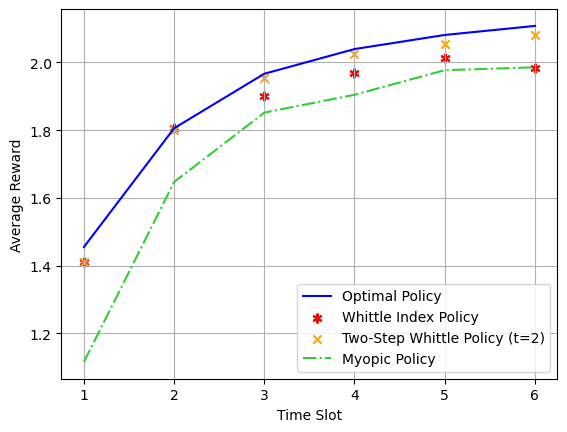

In [168]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

In [146]:
(whittle - myopic).sum()/(myopic.sum()*6)
(whittle_t2 - myopic).sum()/(myopic.sum()*6)
(y - myopic).sum()/(myopic.sum()*6)


np.float64(0.0031941382374212016)

In [147]:
(whittle - myopic).sum()/(6)

np.float64(0.028135683616302476)

In [148]:
(whittle_t2 - myopic).sum()/(6)

np.float64(0.03226388736981389)

In [149]:
(y - myopic).sum()/(6)

np.float64(0.03751337287007972)

In [150]:
order_slice = slice(ORDER_START_SLOT - 1, None)
print('myopic   ', myopic)
print('t=1      ', whittle)
print('t=2      ', whittle_t2)
print('optimal  ', y)
print('max(t=2 - optimal) =', np.max(whittle_t2 - y))
print('same curves?', np.allclose(myopic, whittle) and np.allclose(whittle, whittle_t2) and np.allclose(whittle_t2, y))
print(f'order from slot {ORDER_START_SLOT}:',
      np.all(y[order_slice] + 1e-9 >= whittle_t2[order_slice]) and
      np.all(whittle_t2[order_slice] + 1e-9 >= whittle[order_slice]) and
      np.all(whittle[order_slice] + 1e-9 >= myopic[order_slice]))
print('final gaps [optimal-t2, t2-t1, t1-myopic] =',
      y[-1] - whittle_t2[-1],
      whittle_t2[-1] - whittle[-1],
      whittle[-1] - myopic[-1])

myopic    [1.95002418 1.87915879 1.93752539 1.96669809 1.99896459 2.01207146]
t=1       [1.9188773  1.90784496 1.99586907 2.01064451 2.0360265  2.04399426]
t=2       [1.9188773  1.90784496 2.00005873 2.01563824 2.04382777 2.05177881]
optimal   [1.95002418 1.90784496 2.00005873 2.01580257 2.04385202 2.05194028]
max(t=2 - optimal) = -4.884981308350689e-14
same curves? False
order from slot 2: True
final gaps [optimal-t2, t2-t1, t1-myopic] = 0.00016146785685577925 0.007784551901782066 0.0319228001254519


### Case1

In [151]:
reward = np.array([[0.        , 1.80831007, 1.9332522 ],
       [0.        , 0.42644543, 0.55181658],
       [0.        , 2.7213554 , 2.85282492],
       [0.        , 1.12682684, 1.93197637],
       [0.        , 2.68601711, 2.99572877],
       [0.        , 2.49407322, 2.58241065],
       [0.        , 0.59326415, 1.68689499]])

initial_dist = np.array([[0.49704444, 0.05227707, 0.45067849],
       [0.18453831, 0.33723995, 0.47822175],
       [0.59309035, 0.23293529, 0.17397436],
       [0.39936201, 0.33099891, 0.26963908],
       [0.53177899, 0.38324804, 0.08497298],
       [0.52165431, 0.25938047, 0.21896522],
       [0.28171285, 0.41799492, 0.30029223]])

transition_matrics = np.array([[[0.70457409, 0.00453734, 0.29088857],
        [0.4000003 , 0.19930379, 0.40069591],
        [0.64872323, 0.16659453, 0.18468224]],

       [[0.31997802, 0.274677  , 0.40534498],
        [0.34956085, 0.3566891 , 0.29375005],
        [0.29201074, 0.54484353, 0.16314572]],

       [[0.39986221, 0.38034049, 0.2197973 ],
        [0.35522717, 0.19133107, 0.45344176],
        [0.1152867 , 0.36866368, 0.51604962]],

       [[0.0709633 , 0.31240426, 0.61663244],
        [0.27689656, 0.20209269, 0.52101075],
        [0.34136759, 0.22654526, 0.43208715]],

       [[0.09180806, 0.61133781, 0.29685413],
        [0.33050289, 0.06280687, 0.60669024],
        [0.16539613, 0.25910409, 0.57549978]],

       [[0.40964548, 0.1499325 , 0.44042202],
        [0.28048822, 0.27680978, 0.442702  ],
        [0.50548554, 0.14987491, 0.34463955]],

       [[0.39478396, 0.5038836 , 0.10133244],
        [0.47624017, 0.49767375, 0.02608608],
        [0.14808418, 0.76908525, 0.08283057]]])

myopic, whittle, whittle_t2, y = (
  np.array([1.18606546, 1.75344912, 1.91612424, 2.01924411, 2.08756099, 2.12744282]),
  np.array([1.26912366, 1.77793021, 1.95351429, 2.04312071, 2.10353696, 2.14431486]),
  np.array([1.11984971, 1.79079157, 1.96644322, 2.05486663, 2.11191247, 2.14583743]),
  np.array([1.28396677, 1.79846197, 1.96900111, 2.05619712, 2.11455427, 2.15433538])
  )


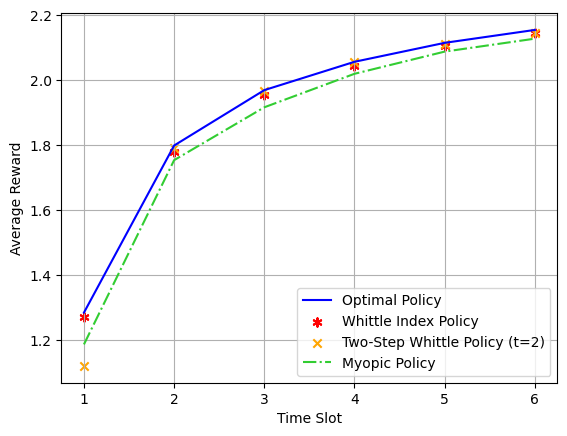

In [152]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

### Case2

In [153]:
reward = np.array([[0.        , 0.355056  , 1.6161346 ],
       [0.        , 1.7134983 , 2.48138832],
       [0.        , 2.8651571 , 2.90396562],
       [0.        , 2.04101503, 2.82242325],
       [0.        , 2.28660228, 2.61316137],
       [0.        , 1.31791203, 2.85504394],
       [0.        , 2.65115382, 2.72572038]])

initial_dist = np.array([[0.29620142, 0.25544789, 0.44835069],
       [0.29139465, 0.43243079, 0.27617455],
       [0.51304214, 0.11008683, 0.37687102],
       [0.39603765, 0.39730221, 0.20666014],
       [0.4592655 , 0.42712644, 0.11360806],
       [0.28727753, 0.42148864, 0.29123383],
       [0.45143053, 0.53189315, 0.01667632]])

transition_matrics = np.array([[[0.17407341, 0.47045002, 0.35547657],
        [0.28795542, 0.41427797, 0.29776661],
        [0.05842501, 0.65856541, 0.28300959]],

       [[0.59189354, 0.28963538, 0.11847108],
        [0.36428339, 0.33817484, 0.29754177],
        [0.11463057, 0.23105962, 0.65430981]],

       [[0.50369264, 0.09263152, 0.40367584],
        [0.40372   , 0.33611142, 0.26016858],
        [0.24860496, 0.43473492, 0.31666012]],

       [[0.37334982, 0.36674939, 0.25990079],
        [0.289981  , 0.37585209, 0.33416691],
        [0.41201596, 0.4444371 , 0.14354693]],

       [[0.39567893, 0.17936755, 0.42495352],
        [0.02478173, 0.61215259, 0.36306568],
        [0.60665026, 0.18247672, 0.21087302]],

       [[0.19564601, 0.61836457, 0.18598942],
        [0.46786383, 0.14206035, 0.39007581],
        [0.04160295, 0.31767298, 0.64072408]],

       [[0.26579664, 0.32718714, 0.40701622],
        [0.52448319, 0.0788905 , 0.39662631],
        [0.39828274, 0.1674474 , 0.43426985]]])

myopic, whittle, whittle_t2, y = (
 np.array([1.38463896, 1.63012306, 1.70570843, 1.77007741, 1.80105544, 1.81433474]),
 np.array([1.40040126, 1.64959731, 1.71414889, 1.78668235, 1.82480926, 1.8521723 ]),
 np.array([1.42580468, 1.65425872, 1.72802722, 1.80274506, 1.84238208, 1.87479696]),
 np.array([1.45558554, 1.67730238, 1.77729141, 1.82574618, 1.85408149, 1.87559081]))

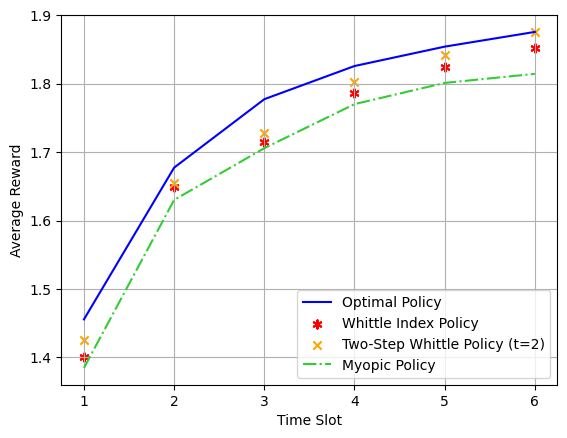

In [154]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

### Case3

In [155]:
reward = np.array([[0.        , 1.81441245, 1.82408642],
       [0.        , 0.10570825, 2.22295355],
       [0.        , 1.55309635, 2.55052736],
       [0.        , 2.02332723, 2.16956123],
       [0.        , 0.38421754, 1.1863107 ],
       [0.        , 2.30039923, 2.78347503],
       [0.        , 1.4012987 , 1.73548033]])

initial_dist = np.array([[0.35658132, 0.30449805, 0.33892062],
       [0.57869495, 0.14150044, 0.27980461],
       [0.46415663, 0.47477523, 0.06106814],
       [0.44042107, 0.36438059, 0.19519834],
       [0.42964929, 0.39199859, 0.17835213],
       [0.55250382, 0.11989682, 0.32759936],
       [0.35594574, 0.4848112 , 0.15924306]])

transition_matrics = np.array([[[4.17690002e-01, 3.71158217e-01, 2.11151780e-01],
        [3.89211554e-01, 1.83151016e-01, 4.27637430e-01],
        [5.82869998e-01, 4.00599266e-01, 1.65307352e-02]],

       [[3.10169363e-01, 2.75930006e-01, 4.13900631e-01],
        [4.01770595e-01, 3.97924674e-01, 2.00304731e-01],
        [4.29807276e-01, 2.77655769e-01, 2.92536955e-01]],

       [[3.49933596e-01, 4.50062010e-01, 2.00004394e-01],
        [4.47322170e-01, 4.28652189e-01, 1.24025641e-01],
        [3.52115719e-01, 1.68361329e-01, 4.79522952e-01]],

       [[3.65748097e-01, 2.95588623e-01, 3.38663280e-01],
        [3.26448870e-01, 2.17208182e-01, 4.56342948e-01],
        [2.16492000e-01, 3.50799745e-01, 4.32708255e-01]],

       [[6.07016213e-01, 9.11205644e-02, 3.01863223e-01],
        [1.32378053e-01, 4.57871193e-01, 4.09750754e-01],
        [2.67822681e-01, 2.37144160e-01, 4.95033159e-01]],

       [[1.79655258e-01, 3.58564550e-01, 4.61780193e-01],
        [3.61737275e-01, 4.79410542e-01, 1.58852182e-01],
        [2.94229368e-01, 1.19151274e-01, 5.86619357e-01]],

       [[4.31353987e-04, 7.07210373e-01, 2.92358273e-01],
        [2.80870590e-01, 6.70259027e-01, 4.88703832e-02],
        [1.12749525e-01, 6.33269918e-01, 2.53980558e-01]]])

myopic, whittle, whittle_t2, y = (
 np.array([1.15380869, 1.51845118, 1.62985939, 1.6837807 , 1.70415056, 1.72330442]),
 np.array([1.17971114, 1.55489419, 1.64677568, 1.69031537, 1.71629243, 1.73078762]),
 np.array([1.15104066, 1.54180111, 1.6659446 , 1.70181017, 1.73971585, 1.76481485]),
 np.array([1.18767519, 1.58175864, 1.67080037, 1.71884111, 1.74689892, 1.76558195])
 )

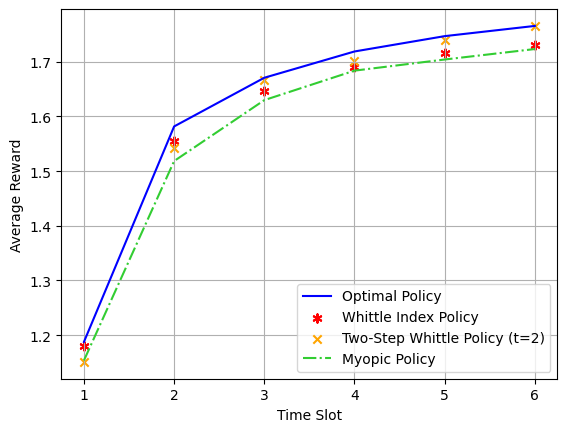

In [156]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

### Case4

In [157]:
reward = np.array([[0.        , 2.14090088, 2.73650274],
       [0.        , 0.38233039, 0.77571876],
       [0.        , 0.16810306, 0.59509045],
       [0.        , 1.21606907, 2.24118   ],
       [0.        , 2.56115065, 2.92900787],
       [0.        , 1.73800036, 2.29671997],
       [0.        , 1.99535741, 2.44884676]])

initial_dist = np.array([[0.3792651 , 0.2949926 , 0.3257423 ],
       [0.66271891, 0.13276758, 0.2045135 ],
       [0.34532499, 0.22434963, 0.43032538],
       [0.48357909, 0.30166805, 0.21475286],
       [0.34789829, 0.51314881, 0.1389529 ],
       [0.4492796 , 0.28171383, 0.26900657],
       [0.45521892, 0.44823497, 0.09654611]])

transition_matrics = np.array([[[0.35797709, 0.5389726 , 0.10305032],
        [0.38728732, 0.3240985 , 0.28861418],
        [0.02845594, 0.57372055, 0.3978235 ]],

       [[0.30592449, 0.27830338, 0.41577213],
        [0.43373697, 0.15605376, 0.41020927],
        [0.36905601, 0.14142524, 0.48951874]],

       [[0.27936541, 0.16366833, 0.55696627],
        [0.35335771, 0.33666359, 0.3099787 ],
        [0.28248112, 0.3769605 , 0.34055838]],

       [[0.07552956, 0.50612957, 0.41834087],
        [0.05290175, 0.51262683, 0.43447142],
        [0.32605575, 0.21841863, 0.45552561]],

       [[0.1682597 , 0.33103803, 0.50070227],
        [0.42073611, 0.22200287, 0.35726102],
        [0.06544665, 0.49516375, 0.4393896 ]],

       [[0.48666699, 0.05269164, 0.46064137],
        [0.48989268, 0.4563794 , 0.05372792],
        [0.17580402, 0.4211114 , 0.40308458]],

       [[0.22347835, 0.49346825, 0.2830534 ],
        [0.25683235, 0.58159895, 0.1615687 ],
        [0.49354014, 0.48539112, 0.02106874]]])

myopic, whittle, whittle_t2, y = (
 np.array([1.27560292, 1.63035242, 1.76593723, 1.85874378, 1.91706194, 1.96286538]),
 np.array([1.29066015, 1.6574761 , 1.77974009, 1.88887876, 1.94714674, 2.00301938]),
 np.array([1.34892149, 1.68246886, 1.82302251, 1.90455962, 1.96673106, 2.01001042]),
 np.array([1.30922195, 1.67707156, 1.82408574, 1.90592881, 1.96698035, 2.01256792]))


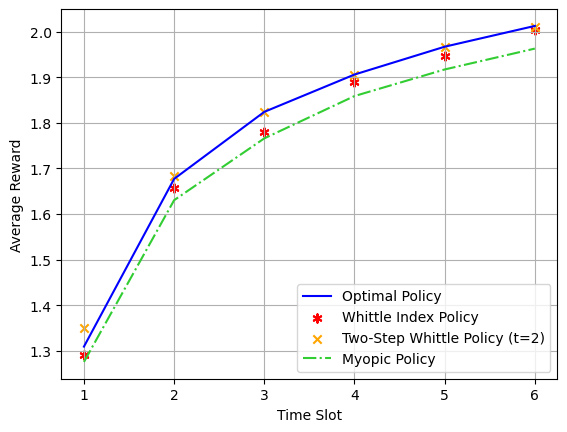

In [158]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

### Case5

In [159]:
reward = np.array([[0.        , 0.07463691, 2.75876931],
       [0.        , 2.36837694, 2.6144538 ],
       [0.        , 0.79204422, 1.63502257],
       [0.        , 0.18392055, 2.68919583],
       [0.        , 0.9185889 , 2.36310488],
       [0.        , 1.97004317, 2.98063133],
       [0.        , 2.10017685, 2.891396  ]])

initial_dist = np.array([[0.7305568 , 0.16358061, 0.10586259],
       [0.41471911, 0.21151522, 0.37376567],
       [0.51817634, 0.41273   , 0.06909366],
       [0.24167746, 0.24893883, 0.50938372],
       [0.48519792, 0.16196673, 0.35283535],
       [0.44271974, 0.26071656, 0.29656369],
       [0.70816964, 0.04614252, 0.24568784]])

transition_matrics = np.array([[[0.29000266, 0.48812819, 0.22186916],
        [0.23858278, 0.35999205, 0.40142517],
        [0.02734673, 0.7920613 , 0.18059196]],

       [[0.36811356, 0.32122403, 0.31066241],
        [0.71518248, 0.01085957, 0.27395796],
        [0.50943376, 0.23862204, 0.25194421]],

       [[0.08326106, 0.33575825, 0.58098069],
        [0.40161177, 0.13732687, 0.46106136],
        [0.32855914, 0.3929724 , 0.27846846]],

       [[0.27242072, 0.24250854, 0.48507074],
        [0.40836373, 0.23182276, 0.35981351],
        [0.11429926, 0.452313  , 0.43338774]],

       [[0.58179847, 0.17218598, 0.24601555],
        [0.29934944, 0.5388664 , 0.16178416],
        [0.07217762, 0.32746028, 0.6003621 ]],

       [[0.38302341, 0.30227495, 0.31470164],
        [0.4505714 , 0.14880827, 0.40062033],
        [0.52506976, 0.29325292, 0.18167732]],

       [[0.2417369 , 0.59268591, 0.16557719],
        [0.10101515, 0.62370148, 0.27528338],
        [0.33113655, 0.44202168, 0.22684177]]])

myopic, whittle, whittle_t2, y = (
 np.array([1.41076718, 1.71082613, 1.82485546, 1.87149117, 1.90202165, 1.93103034]),
 np.array([1.41115079, 1.71830606, 1.82705728, 1.87441614, 1.90373014, 1.93844667]),
 np.array([1.41300393, 1.74606759, 1.85447846, 1.90382932, 1.94098511, 1.96447924]),
 np.array([1.44827871, 1.75570272, 1.86119486, 1.91056829, 1.94282545, 1.96489346])
 )

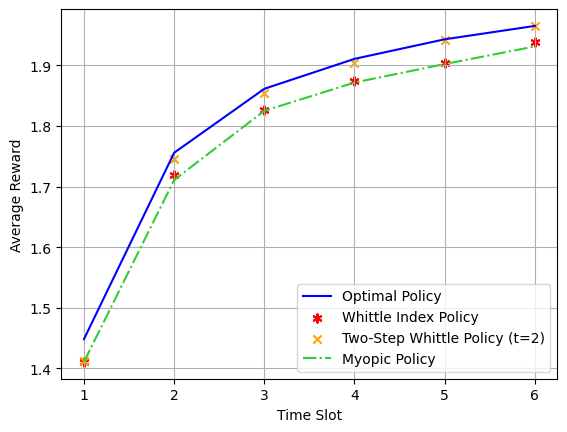

In [160]:
plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Two-Step Whittle Policy (t=2)', c='orange', marker='x')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()

### Case6

In [161]:
reward_set = np.array([[0.        , 0.33874921, 1.3200121 ],
 [0.        , 1.50828598, 2.54129054],
 [0.        , 2.5347471,  2.58377991],
 [0.        , 2.64199039, 2.93256822],
 [0.        , 2.67315138, 2.67994699],
 [0.        , 2.89824782, 2.9654205 ],
 [0.        , 2.43950416, 2.79139285]])


initial_dist = np.array([[0.2415332,  0.66935099, 0.08911582],
 [0.47695854, 0.23241847, 0.29062299],
 [0.47705007, 0.41022495, 0.11272498],
 [0.65070664, 0.18453991, 0.16475345],
 [0.47302527, 0.19046044, 0.33651429],
 [0.5649414, 0.34490864, 0.09014996],
 [0.42524639, 0.42438585, 0.15036775]])


transition_matrices = np.array([[[0.13188605, 0.78766523, 0.08044873],
  [0.26963976, 0.4294423,  0.30091794],
  [0.0063566, 0.25092022, 0.74272318]],

 [[0.31891589, 0.18923001, 0.4918541 ],
  [0.08588111, 0.43018065, 0.48393823],
  [0.01452815, 0.59736399, 0.38810787]],

 [[0.083292  , 0.36439337, 0.55231463],
  [0.32524423, 0.22889188, 0.44586389],
  [0.06646661, 0.46084742, 0.47268596]],

 [[0.55276821, 0.38292396, 0.06430783],
  [0.23249692, 0.45148461, 0.31601847],
  [0.46238235, 0.03363637, 0.50398128]],

 [[0.24937717, 0.43320515, 0.31741768],
  [0.07117788, 0.38312891, 0.54569321],
  [0.5404479 , 0.44546327, 0.01408883]],

 [[0.35582274, 0.37901848, 0.26515878],
  [0.30102894, 0.57550558, 0.12346548],
  [0.45859968, 0.46740488, 0.07399544]],

 [[0.47957692, 0.08055315, 0.43986993],
  [0.47421319, 0.32502886, 0.20075795],
  [0.27958345, 0.56093309, 0.15948346]]])


myopic, whittle, whittle_t2, y = (
np.array([1.11560847, 1.64683963, 1.85182816, 1.90438163, 1.97702123, 1.98556973]),
np.array([1.28285488, 1.69317712, 1.89310875, 1.97786113, 2.04975774, 2.09007436]),
np.array([1.3909917 , 1.76662388, 1.94333305, 2.02474965, 2.06413562, 2.10273223]),
np.array([1.45502651, 1.79284443, 1.95603097, 2.02897205, 2.06961081, 2.10654375])
)

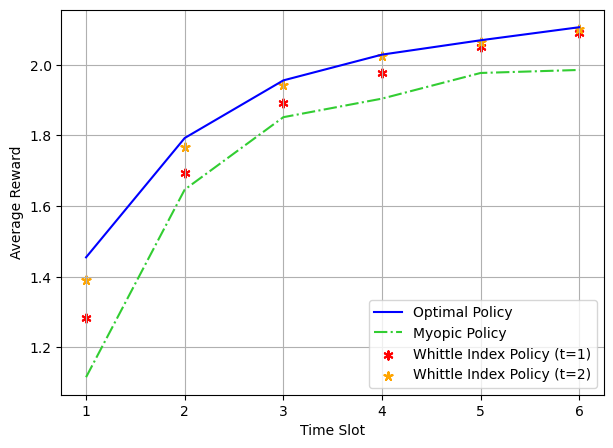

In [162]:
plt.figure(figsize=(7,5))

plt.plot(range(1, 7), y, label='Optimal Policy', c='blue')
plt.plot(range(1, 7), myopic, label='Myopic Policy', c='limegreen', linestyle='-.')
plt.scatter(range(1, 7), whittle, label='Whittle Index Policy (t=1)', c='red', marker=(6,2,0))
plt.scatter(range(1, 7), whittle_t2, label='Whittle Index Policy (t=2)', c='orange', marker=(5,2,0))

plt.grid()
plt.xlabel('Time Slot')
plt.ylabel('Average Reward')
plt.legend()